# Objective

HDB is interested to monitor price trends for Executive Condominiums (ECs), a type of residential property developed and sold by private developers (i.e. 
with facilities similar to condominiums) yet subsidised to some degree by the government (first-time buyers are eligible for CPF housing grants, similar to 
HDB flats, if they buy a new EC during its launch).
HDB is particularly interested to predict the price of new EC flats at two specific points in time:

• 5 years after lease commencement, when an EC reaches its Minimum Occupancy Period (MOP), resulting in a significant number of flats flooding 
the resale market; and

• 10 years after lease commencement, when an EC becomes privatised and generally indistinguishable from comparable private condominiums.




### Import Libraries

In [37]:
import math 
import glob
import json
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


%matplotlib inline

# Load Data

In [38]:
# Load data
DATA_DIR = Path.cwd() / "data"
if Path.cwd().name == "notebook":
    DATA_DIR = Path.cwd().parent / "data"

json_paths = sorted(glob.glob(str(DATA_DIR / "*.json")))

dfs = []
for p in json_paths:
    with open(p, encoding="utf-8") as f:
        payload = json.load(f)
    dfs.append(pd.DataFrame(payload["Result"]))

df_raw = pd.concat(dfs, ignore_index=True)



In [39]:
df_raw.head()

,street,x,project,y,transaction,marketSegment
0,NEO PEE TECK LANE,20862.4977,LANDED HOUSING DEVELOPMENT,30526.52507,"[{'area': '257', 'floorRange': '-', 'noOfUnits...",RCR
1,ZEHNDER ROAD,NaN,LANDED HOUSING DEVELOPMENT,NaN,"[{'area': '308', 'floorRange': '-', 'noOfUnits...",RCR
2,BEACH ROAD,NaN,AUREA,NaN,"[{'area': '66', 'floorRange': '21-25', 'noOfUn...",CCR
3,COVE DRIVE,28382.47067,TURQUOISE,25008.33592,"[{'area': '195', 'floorRange': '01-05', 'noOfU...",CCR
4,ALEXANDRA VIEW,26204.50079,ARTRA,30270.56219,"[{'area': '97', 'floorRange': '11-15', 'noOfUn...",RCR


### Normalize the data

In [40]:
df = pd.json_normalize(
    df_raw.to_dict("records"),
    record_path="transaction",
    meta=["street", "x", "project", "y", "marketSegment"],
)

df.head()

,area,floorRange,noOfUnits,contractDate,typeOfSale,price,propertyType,district,typeOfArea,tenure,nettPrice,street,x,project,y,marketSegment
0,257,-,1,0522,3,4600000,Terrace,05,Land,Freehold,NaN,NEO PEE TECK LANE,20862.4977,LANDED HOUSING DEVELOPMENT,30526.52507,RCR
1,308,-,1,0921,3,5200000,Semi-detached,05,Land,Freehold,NaN,ZEHNDER ROAD,NaN,LANDED HOUSING DEVELOPMENT,NaN,RCR
2,228.4,-,1,0724,3,5188888,Semi-detached,05,Land,Freehold,NaN,ZEHNDER ROAD,NaN,LANDED HOUSING DEVELOPMENT,NaN,RCR
3,66,21-25,1,0925,1,2065000,Apartment,07,Strata,99 yrs lease commencing from 2024,NaN,BEACH ROAD,NaN,AUREA,NaN,CCR
4,60,16-20,1,0825,1,1870000,Apartment,07,Strata,99 yrs lease commencing from 2024,NaN,BEACH ROAD,NaN,AUREA,NaN,CCR


In [41]:
df.tail()

,area,floorRange,noOfUnits,contractDate,typeOfSale,price,propertyType,district,typeOfArea,tenure,nettPrice,street,x,project,y,marketSegment
139632,204,-,1,0421,2,4150000,Semi-detached,28,Land,999 yrs lease commencing from 1879,NaN,GERALD CRESCENT,32836.6471,GERALD MUGLISTON ESTATE,40981.74326,OCR
139633,204,-,1,0821,2,4150000,Semi-detached,28,Land,999 yrs lease commencing from 1879,NaN,GERALD CRESCENT,32836.6471,GERALD MUGLISTON ESTATE,40981.74326,OCR
139634,434,-,1,0623,3,4700000,Detached,28,Land,999 yrs lease commencing from 1879,NaN,GERALD CRESCENT,32836.6471,GERALD MUGLISTON ESTATE,40981.74326,OCR
139635,208.2,-,1,0324,3,2600000,Semi-detached,28,Land,99 yrs lease commencing from 1997,NaN,GERALD CRESCENT,32836.6471,GERALD MUGLISTON ESTATE,40981.74326,OCR
139636,684.6,-,1,0625,3,16700000,Detached,28,Land,999 yrs lease commencing from 1879,NaN,GERALD CRESCENT,32836.6471,GERALD MUGLISTON ESTATE,40981.74326,OCR


# Exploratory Data Analysis

1. Structural Investigation
Check for

- predictor and target
- Missing values
- Duplicated values
- Type of variable, Data type and Variable Category
- Categorical Variable Cardinality

In [42]:
# Check the shape of the dataframe
print('Shape of the dataframe:', df.shape)
print('-'*80)
# Check the datatype information of the features
print('Datatype information of the features:', df.info())

Shape of the dataframe: (139637, 16)
--------------------------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 139637 entries, 0 to 139636
Data columns (total 16 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   area           139637 non-null  str  
 1   floorRange     139637 non-null  str  
 2   noOfUnits      139637 non-null  str  
 3   contractDate   139637 non-null  str  
 4   typeOfSale     139637 non-null  str  
 5   price          139637 non-null  str  
 6   propertyType   139637 non-null  str  
 7   district       139637 non-null  str  
 8   typeOfArea     139637 non-null  str  
 9   tenure         139637 non-null  str  
 10  nettPrice      178 non-null     str  
 11  street         139637 non-null  str  
 12  x              114481 non-null  str  
 13  project        139637 non-null  str  
 14  y              114481 non-null  str  
 15  marketSegment  139637 non-null  str  
dtypes: 

### Observation 
- nettPrice , x and y have missing values
- All the datatypes in the dataframe are str

In [43]:
# Check for missing values in each column
print('Missing values in each column:', df.isnull().sum())

Missing values in each column: area                  0
floorRange            0
noOfUnits             0
contractDate          0
typeOfSale            0
price                 0
propertyType          0
district              0
typeOfArea            0
tenure                0
nettPrice        139459
street                0
x                 25156
project               0
y                 25156
marketSegment         0
dtype: int64


In [44]:
# check for missing values in each column as a percentage of whole dataset
print(f'Percentage of missing values in each column{(df.isnull().sum() / df.shape[0]) * 100}')

Percentage of missing values in each columnarea              0.000000
floorRange        0.000000
noOfUnits         0.000000
contractDate      0.000000
typeOfSale        0.000000
price             0.000000
propertyType      0.000000
district          0.000000
typeOfArea        0.000000
tenure            0.000000
nettPrice        99.872527
street            0.000000
x                18.015282
project           0.000000
y                18.015282
marketSegment     0.000000
dtype: float64


### Observation 
nettPrice - almost 99.8% missing

x - 18.01 % missing

y - 18.01 % missing

In [45]:
# Check for duplicates in the dataframe
print('Duplicated values in the dataframe:',  df.duplicated().sum())


Duplicated values in the dataframe: 8811


In [46]:
df[df.duplicated()].head(350)

,area,floorRange,noOfUnits,contractDate,typeOfSale,price,propertyType,district,typeOfArea,tenure,nettPrice,street,x,project,y,marketSegment
130,77,06-10,1,0922,2,1700000,Apartment,03,Strata,99 yrs lease commencing from 2016,NaN,ALEXANDRA VIEW,26204.50079,ARTRA,30270.56219,RCR
660,89,31-35,1,0421,1,1653000,Apartment,05,Strata,99 yrs lease commencing from 2019,NaN,CLEMENTI AVENUE 1,20628.9284312595,CLAVON,32314.2656786125,OCR
686,89,36-40,1,0521,1,1663000,Apartment,05,Strata,99 yrs lease commencing from 2019,NaN,CLEMENTI AVENUE 1,20628.9284312595,CLAVON,32314.2656786125,OCR
696,89,31-35,1,0421,1,1658000,Apartment,05,Strata,99 yrs lease commencing from 2019,NaN,CLEMENTI AVENUE 1,20628.9284312595,CLAVON,32314.2656786125,OCR
775,89,16-20,1,0824,2,2080000,Apartment,05,Strata,99 yrs lease commencing from 2019,NaN,CLEMENTI AVENUE 1,20628.9284312595,CLAVON,32314.2656786125,OCR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8038,113,21-25,1,0122,1,1710000,Apartment,05,Strata,99 yrs lease commencing from 2019,NaN,JALAN LEMPENG,19797.85798,PARC CLEMATIS,33186.6657,OCR
8040,120,16-20,1,0122,1,2339000,Apartment,05,Strata,99 yrs lease commencing from 2019,NaN,JALAN LEMPENG,19797.85798,PARC CLEMATIS,33186.6657,OCR
8042,139,21-25,1,0721,1,2553000,Apartment,05,Strata,99 yrs lease commencing from 2019,NaN,JALAN LEMPENG,19797.85798,PARC CLEMATIS,33186.6657,OCR
8044,139,06-10,1,0821,1,2476000,Apartment,05,Strata,99 yrs lease commencing from 2019,NaN,JALAN LEMPENG,19797.85798,PARC CLEMATIS,33186.6657,OCR


### Observation
- There are 8811 duplicated rows

In [47]:
# Check for unique values in each column
df_column_list = df.columns
for column_name in df_column_list:
    print(df[column_name].value_counts())

area
63       2342
87       2049
65       1979
68       1978
85       1824
         ... 
490.4       1
437.2       1
304.1       1
901.9       1
660.7       1
Name: count, Length: 3908, dtype: int64
floorRange
01-05    45457
06-10    32481
11-15    22867
-        13411
16-20    11542
21-25     6110
26-30     3348
31-35     2094
36-40     1232
41-45      460
46-50      263
51-55      202
56-60      106
61-65       41
B1-B5       14
66-70        8
71-75        1
Name: count, dtype: int64
noOfUnits
1      139571
2          34
4           5
3           5
6           4
25          2
72          1
31          1
7           1
11          1
14          1
104         1
84          1
9           1
446         1
10          1
40          1
43          1
12          1
60          1
120         1
160         1
Name: count, dtype: int64
contractDate
1124    4312
1025    3998
0825    3905
0721    3885
1121    3443
        ... 
0223    1473
1223    1359
0224    1335
0123    1263
0426      94
Name: cou

In [48]:
# Convert each column to the specified datatypes
df = df.astype({
    'area': float,                 # int in schema, but may have floats in source
    'floorRange': str,
    'noOfUnits': 'Int64',            # nullable integer
    'contractDate': 'Int64',
    'typeOfSale': 'Int64',
    'price': 'Int64',
    'propertyType': str,
    'district': 'Int64',
    'typeOfArea': str,
    'tenure': str,
    'nettPrice': 'Int64',
    'street': str,
    'x': float,                    # in outputs x and y look like floats
    'y': float,
    'marketSegment': str,
    'project': str
})


In [49]:
#check the dataframe basic numerical statistics
df.describe()

,area,noOfUnits,contractDate,typeOfSale,price,district,nettPrice,x,y
count,139637.000000,139637.0,139637.0,139637.0,139637.0,139637.0,178.0,114481.000000,114481.000000
mean,120.223174,1.009553,683.240774,2.258012,2290606.462456,15.713758,2539841.050562,30289.560466,35885.735508
std,236.957677,1.38946,331.317151,0.947263,5115843.212273,7.050152,2478362.308586,6603.647182,4607.650514
min,24.000000,1.0,122.0,1.0,320000.0,1.0,932900.0,12232.347781,24528.350538
25%,69.000000,1.0,422.0,1.0,1280000.0,10.0,1442700.0,26183.911600,32558.002250
50%,95.000000,1.0,721.0,3.0,1708000.0,16.0,1919958.5,29949.898960,35125.608220
75%,125.000000,1.0,1021.0,3.0,2480000.0,21.0,2423700.0,35073.555370,38979.862438
max,57584.000000,446.0,1225.0,3.0,890000000.0,28.0,14463000.0,43883.552715,49250.765840


In [50]:
# Split contractDate (MMYY) into contractMonth and contractYear
df['contractMonth'] = df['contractDate'].astype(str).str.zfill(4).str[:2].astype(int)
df['contractYear'] = df['contractDate'].astype(str).str.zfill(4).str[2:].astype(int)

In [51]:
df.head(5)

,area,floorRange,noOfUnits,contractDate,typeOfSale,price,propertyType,district,typeOfArea,tenure,nettPrice,street,x,project,y,marketSegment,contractMonth,contractYear
0,257.0,-,1,522,3,4600000,Terrace,5,Land,Freehold,<NA>,NEO PEE TECK LANE,20862.4977,LANDED HOUSING DEVELOPMENT,30526.52507,RCR,5,22
1,308.0,-,1,921,3,5200000,Semi-detached,5,Land,Freehold,<NA>,ZEHNDER ROAD,NaN,LANDED HOUSING DEVELOPMENT,NaN,RCR,9,21
2,228.4,-,1,724,3,5188888,Semi-detached,5,Land,Freehold,<NA>,ZEHNDER ROAD,NaN,LANDED HOUSING DEVELOPMENT,NaN,RCR,7,24
3,66.0,21-25,1,925,1,2065000,Apartment,7,Strata,99 yrs lease commencing from 2024,<NA>,BEACH ROAD,NaN,AUREA,NaN,CCR,9,25
4,60.0,16-20,1,825,1,1870000,Apartment,7,Strata,99 yrs lease commencing from 2024,<NA>,BEACH ROAD,NaN,AUREA,NaN,CCR,8,25


In [52]:
df_ec = df[df['propertyType'] == 'Executive Condominium'].copy()
print(df_ec.shape)
print(df_ec.info())


(17439, 18)
<class 'pandas.DataFrame'>
Index: 17439 entries, 53415 to 139557
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   area           17439 non-null  float64
 1   floorRange     17439 non-null  str    
 2   noOfUnits      17439 non-null  Int64  
 3   contractDate   17439 non-null  Int64  
 4   typeOfSale     17439 non-null  Int64  
 5   price          17439 non-null  Int64  
 6   propertyType   17439 non-null  str    
 7   district       17439 non-null  Int64  
 8   typeOfArea     17439 non-null  str    
 9   tenure         17439 non-null  str    
 10  nettPrice      0 non-null      Int64  
 11  street         17439 non-null  str    
 12  x              12944 non-null  float64
 13  project        17439 non-null  str    
 14  y              12944 non-null  float64
 15  marketSegment  17439 non-null  str    
 16  contractMonth  17439 non-null  int64  
 17  contractYear   17439 non-null  int64  
dtypes: In

In [53]:
df_ec = df_ec.drop(columns=['nettPrice'])
df_ec = df_ec.drop(columns=['x', 'y'])


In [54]:
df_ec

,area,floorRange,noOfUnits,contractDate,typeOfSale,price,propertyType,district,typeOfArea,tenure,street,project,marketSegment,contractMonth,contractYear
53415,77.0,06-10,1,921,3,818000,Executive Condominium,19,Strata,99 yrs lease commencing from 2010,PUNGGOL DRIVE,RIVERPARC RESIDENCE,OCR,9,21
53416,100.0,01-05,1,1021,3,1100000,Executive Condominium,19,Strata,99 yrs lease commencing from 2010,PUNGGOL DRIVE,RIVERPARC RESIDENCE,OCR,10,21
53417,100.0,16-20,1,1021,3,1030000,Executive Condominium,19,Strata,99 yrs lease commencing from 2010,PUNGGOL DRIVE,RIVERPARC RESIDENCE,OCR,10,21
53418,92.0,01-05,1,1121,3,952000,Executive Condominium,19,Strata,99 yrs lease commencing from 2010,PUNGGOL DRIVE,RIVERPARC RESIDENCE,OCR,11,21
53419,100.0,01-05,1,821,3,1050000,Executive Condominium,19,Strata,99 yrs lease commencing from 2010,PUNGGOL DRIVE,RIVERPARC RESIDENCE,OCR,8,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139553,118.0,11-15,1,925,3,1840000,Executive Condominium,27,Strata,99 yrs lease commencing from 2014,SEMBAWANG CRESCENT,PARC LIFE,OCR,9,25
139554,71.0,11-15,1,725,3,1090000,Executive Condominium,27,Strata,99 yrs lease commencing from 2014,SEMBAWANG CRESCENT,PARC LIFE,OCR,7,25
139555,103.0,01-05,1,625,3,1470000,Executive Condominium,27,Strata,99 yrs lease commencing from 2014,SEMBAWANG CRESCENT,PARC LIFE,OCR,6,25
139556,71.0,01-05,1,625,3,1040000,Executive Condominium,27,Strata,99 yrs lease commencing from 2014,SEMBAWANG CRESCENT,PARC LIFE,OCR,6,25


In [55]:
# Check what are the unique values in floorRange
unique_floor_ranges = df_ec['floorRange'].unique()
print(unique_floor_ranges)

<StringArray>
['06-10', '01-05', '16-20', '11-15', '21-25', '26-30', '31-35']
Length: 7, dtype: str


In [56]:
# Create new columns 'lower_floor_range' and 'higher_floor_range' by splitting 'floorRange'
df_ec['lower_floor_range'] = df_ec['floorRange'].str.extract(r'(\d+)')
df_ec['higher_floor_range'] = df_ec['floorRange'].str.extract(r'-(\d+)')

In [57]:
df_ec = df_ec.drop(columns=['floorRange'])

In [58]:
df_ec.info()

<class 'pandas.DataFrame'>
Index: 17439 entries, 53415 to 139557
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   area                17439 non-null  float64
 1   noOfUnits           17439 non-null  Int64  
 2   contractDate        17439 non-null  Int64  
 3   typeOfSale          17439 non-null  Int64  
 4   price               17439 non-null  Int64  
 5   propertyType        17439 non-null  str    
 6   district            17439 non-null  Int64  
 7   typeOfArea          17439 non-null  str    
 8   tenure              17439 non-null  str    
 9   street              17439 non-null  str    
 10  project             17439 non-null  str    
 11  marketSegment       17439 non-null  str    
 12  contractMonth       17439 non-null  int64  
 13  contractYear        17439 non-null  int64  
 14  lower_floor_range   17439 non-null  str    
 15  higher_floor_range  17439 non-null  str    
dtypes: Int64(5), fl

Observation 
- Set datatype
- split contractDate MMYY
- Filter df to EC only
- drop nettPrice as there are 0 non-null values
- Drop x and y coordinates for now. Future we could use this as a feature.
- split floor range into lower_floor_range and higher_floor_range
- drop floorRange


# 2. Content Investigation, Quality Checks and Distribution checks

In [59]:
# Get the columns in list
df_ec_column_list_updated = df_ec.columns
df_ec_column_list_updated

Index(['area', 'noOfUnits', 'contractDate', 'typeOfSale', 'price',
       'propertyType', 'district', 'typeOfArea', 'tenure', 'street', 'project',
       'marketSegment', 'contractMonth', 'contractYear', 'lower_floor_range',
       'higher_floor_range'],
      dtype='str')

In [60]:
# Bring contractMonth and contractYear in line with the rest
df_ec['contractMonth'] = df_ec['contractMonth'].astype('Int64')
df_ec['contractYear']  = df_ec['contractYear'].astype('Int64')

In [61]:
# Split columns by dtype
float_columns = [col for col in df_ec_column_list_updated if df_ec[col].dtype == 'float64']
int_columns = [col for col in df_ec_column_list_updated if df_ec[col].dtype == 'Int64' ]
str_columns = [col for col in df_ec_column_list_updated if df_ec[col].dtype == 'string']

print("Float columns:", float_columns)
print("Int columns:", int_columns)
print("String columns:", str_columns)

Float columns: ['area']
Int columns: ['noOfUnits', 'contractDate', 'typeOfSale', 'price', 'district', 'contractMonth', 'contractYear']
String columns: ['propertyType', 'typeOfArea', 'tenure', 'street', 'project', 'marketSegment', 'lower_floor_range', 'higher_floor_range']


In [62]:
# plot histogram and boxplot for all continous features to check the distribution
def plot_continuous_feature_distributions(df_, float_columns):
    import numpy as np
    import math
    import matplotlib.pyplot as plt

    n = len(float_columns)
    ncols = 2  # one col for histogram, one for boxplot
    nrows = n  # one row per feature

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, nrows * 5))

    # Ensure axes is always 2D even if only one feature
    if n == 1:
        axes = np.array([axes])

    for i, feature in enumerate(float_columns):
        col = df_[feature].dropna()
        value_counts = len(col)

        # --- Histogram ---
        axes[i, 0].hist(col, bins=int(np.round(math.sqrt(value_counts))))
        axes[i, 0].set_title(f'Histogram — {feature}')
        axes[i, 0].set_xlabel(feature)
        axes[i, 0].set_ylabel('Frequency')

        # --- Boxplot ---
        axes[i, 1].boxplot(col)
        axes[i, 1].set_title(f'Boxplot — {feature}')

        # --- Stats as figure row title ---
        mean, median     = col.mean(), col.median()
        min_val, max_val = col.min(), col.max()
        skew, kurt       = col.skew(), col.kurt()
        iqr              = col.quantile(0.75) - col.quantile(0.25)

        stats_text = (
            f'Mean: {mean:.2f}  |  Median: {median:.2f}  |  '
            f'Min: {min_val:.2f}  |  Max: {max_val:.2f}  |  '
            f'Skew: {skew:.2f}  |  Kurt: {kurt:.2f}  |  IQR: {iqr:.2f}'
        )
        # Place stats text between the two plots as a row label
        axes[i, 0].annotate(
            stats_text,
            xy=(1.0, -0.15),
            xycoords='axes fraction',
            ha='center', fontsize=9, color='gray'
        )

    plt.suptitle('Continuous Feature Distributions', fontsize=16, y=1.01)
    plt.tight_layout()
    plt.show()

In [63]:
region_map = {
    # Central
    'BUKIT TIMAH': 'Central', 'NEWTON': 'Central', 'ORCHARD': 'Central',
    'QUEENSTOWN': 'Central', 'RIVER VALLEY': 'Central', 'SENTOSA': 'Central',
    'TANGLIN': 'Central', 'BISHAN': 'Central', 'BUKIT MERAH': 'Central',
    'GEYLANG': 'Central', 'MARINE PARADE': 'Central', 'TOA PAYOH': 'Central',
    'DOWNTOWN': 'Central', 'KALLANG': 'Central', 'MARINA': 'Central',
    'SINGAPORE RIVER': 'Central',

    # North
    'SEMBAWANG': 'North', 'WOODLANDS': 'North', 'YISHUN': 'North',
    'MANDAI': 'North', 'SUNGEI KADUT': 'North',
    'CANBERRA CRESCENT': 'North', 'CANBERRA DRIVE': 'North', 'CANBERRA WALK': 'North',

    # North-East
    'ANG MO KIO': 'North-East', 'HOUGANG': 'North-East', 'PUNGGOL': 'North-East',
    'SENGKANG': 'North-East', 'SERANGOON': 'North-East', 'SELETAR': 'North-East',
    'ANCHORVALE': 'North-East', 'RIVERVALE': 'North-East', 'EDGEFIELD PLAINS': 'North-East',
    'EDGEDALE PLAINS': 'North-East', 'SUMANG WALK': 'North-East',
    'YIO CHU KANG ROAD': 'North-East', 
    'COMPASSVALE BOW': 'North-East',
    'FERNVALE LANE': 'North-East',
    'FERNVALE CLOSE': 'North-East',

    # East
    'BEDOK': 'East', 'CHANGI': 'East', 'PASIR RIS': 'East',
    'PAYA LEBAR': 'East', 'TAMPINES': 'East', 'SIMEI': 'East',
    'JALAN LOYANG BESAR': 'East',

    # West
    'BUKIT BATOK': 'West', 'BUKIT PANJANG': 'West', 'BOON LAY': 'West',
    'CHOA CHU KANG': 'West', 'CLEMENTI': 'West', 'JURONG EAST': 'West',
    'JURONG WEST': 'West', 'TENGAH': 'West', 'TUAS': 'West',
    'PIONEER': 'West',
    'WESTWOOD AVENUE': 'West',
    'TAO CHING ROAD': 'West',
    'SEGAR ROAD': 'West',
    'BANGKIT ROAD': 'West',
    'PLANTATION CLOSE': 'West',
}

import re

def get_zone_from_street(street):
    if pd.isnull(street):
        return None
    street = str(street).upper()
    # Try to match any region key as a substring in the street
    for area in region_map:
        if area in street:
            return region_map[area]
    return None

df_ec['zones'] = df_ec['street'].apply(get_zone_from_street)

In [64]:
# Let's investigate why there are NaN values in df_ec['zones']

# Count total NaN values
nan_count = df_ec['zones'].isna().sum()
print("Number of NaN values in df_ec['zones']:", nan_count)

# Show some rows where zones is NaN
print("\nSample rows where zones is NaN:")
display(df_ec[df_ec['zones'].isna()].head(10))

# Investigate the corresponding 'street' values for the NaN zones
print("\nCorresponding 'street' values for NaN zones:")
print(df_ec[df_ec['zones'].isna()]['street'].unique())

# Check how many of these 'street' values are null
null_street_count = df_ec[df_ec['zones'].isna()]['street'].isna().sum()
print(f"\nNumber of rows where street is NaN among NaN zones: {null_street_count}")

# Check if there could be unmatched street names (not in region_map)
remaining_nonnull_streets = df_ec[(df_ec['zones'].isna()) & (~df_ec['street'].isna())]['street'].unique()
print(f"\nExamples of non-null streets where zones is NaN (possible unmatched):")
for s in remaining_nonnull_streets[:10]:
    print("-", s)

Number of NaN values in df_ec['zones']: 0

Sample rows where zones is NaN:


,area,noOfUnits,contractDate,typeOfSale,price,propertyType,district,typeOfArea,tenure,street,project,marketSegment,contractMonth,contractYear,lower_floor_range,higher_floor_range,zones



Corresponding 'street' values for NaN zones:
<StringArray>
[]
Length: 0, dtype: str

Number of rows where street is NaN among NaN zones: 0

Examples of non-null streets where zones is NaN (possible unmatched):


In [65]:
import numpy as np
import datetime

def get_remaining_lease(tenure):
    """
    Returns remaining lease:
    - 999 for any variant of Freehold
    - 99 for typical leasehold (99 yrs lease*, *99-year lease*, etc)
    - For 999-year leaseholds, returns 999
    - For other digit-year patterns, returns the digit
    - np.nan if cannot deduce
    """
    if pd.isnull(tenure):
        return np.nan

    tenure_s = str(tenure).lower()

    # Freehold
    if "freehold" in tenure_s:
        return 999

    # 999-year lease
    if re.search(r'999[\s\-]*year', tenure_s) or re.search(r'999[\s\-]*yrs', tenure_s):
        return 999

    # 99-year lease
    if re.search(r'99[\s\-]*year', tenure_s) or re.search(r'99[\s\-]*yrs', tenure_s):
        return 99

    # Any other NNN-year lease
    match = re.search(r'(\d{2,4})[\s\-]*(year|yrs)', tenure_s)
    if match:
        return int(match.group(1))

    return np.nan

from datetime import datetime
current_year = datetime.today().year

def smart_remaining_lease(tenure):
    """
    Determines remaining lease from tenure string.
    
    - If 'Freehold': 999
    - If '99 yrs lease commencing from YYYY', calculates: 99 - (current_year - YYYY)
    - If '999 yrs lease ... from YYYY', just 999
    - If ambiguous, falls back to previous get_remaining_lease()
    """
    if pd.isnull(tenure):
        return np.nan

    t = str(tenure).lower().strip()

    if "freehold" in t:
        return 999
    
    # 999-year lease, regardless of commencement year
    if re.search(r'999[\s\-]*year', t) or re.search(r'999[\s\-]*yrs', t):
        return 999

    # 99 yrs lease commencing from YYYY or similar patterns
    match_99 = re.search(r'99[\s\-]*yrs* lease.*?from (\d{4})', t)
    if match_99:
        lease_start = int(match_99.group(1))
        years_passed = current_year - lease_start
        remaining = 99 - years_passed
        if remaining < 0:
            return 0  # Lease expired
        return remaining
    
    # Other NNN-year lease commencing from YYYY
    match_nnn = re.search(r'(\d{2,4})[\s\-]*yrs* lease.*?from (\d{4})', t)
    if match_nnn:
        nnn = int(match_nnn.group(1))
        lease_start = int(match_nnn.group(2))
        years_passed = current_year - lease_start
        remaining = nnn - years_passed
        if remaining < 0:
            return 0
        return remaining

    # Fallback: use old get_remaining_lease logic
    return get_remaining_lease(tenure)

df_ec['remaining_lease'] = df_ec['tenure'].apply(smart_remaining_lease)

print("Sample remaining_lease values:")
print(df_ec[['tenure', 'remaining_lease']].head(10))

print("\nRemaining lease description:")
print(df_ec['remaining_lease'].describe())

Sample remaining_lease values:
                                  tenure  remaining_lease
53415  99 yrs lease commencing from 2010               83
53416  99 yrs lease commencing from 2010               83
53417  99 yrs lease commencing from 2010               83
53418  99 yrs lease commencing from 2010               83
53419  99 yrs lease commencing from 2010               83
53420  99 yrs lease commencing from 2010               83
53421  99 yrs lease commencing from 2010               83
53422  99 yrs lease commencing from 2010               83
53423  99 yrs lease commencing from 2010               83
53424  99 yrs lease commencing from 2010               83

Remaining lease description:
count    17439.000000
mean        88.179024
std          7.372104
min         69.000000
25%         85.000000
50%         87.000000
75%         94.000000
max         99.000000
Name: remaining_lease, dtype: float64


In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_categorical_feature_countplots(df_, cat_columns):
    n = len(cat_columns)
    ncols = 3
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, nrows * 5))
    axes = axes.flatten()  # makes indexing easier

    for i, cat_column in enumerate(cat_columns):
        sns.countplot(x=cat_column, data=df_, ax=axes[i])
        axes[i].set_title(f'Count Plot for {cat_column}')
        axes[i].tick_params(axis='x', rotation=45)

    # Hide any unused subplot slots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

    # Print value counts separately after the plot
    for cat_column in cat_columns:
        print(f'Value counts for {cat_column}:')
        print(df_[cat_column].value_counts())
        print(f'Total count: {df_[cat_column].value_counts().sum()}')
        print("\n")

str_columns.remove('street')
str_columns.remove('project')
str_columns.remove('tenure')
str_columns.append('zones')

In [71]:
def plot_discrete_feature_distributions(df_, discrete_columns):
    import math
    import matplotlib.pyplot as plt
    import seaborn as sns

    n = len(discrete_columns)
    ncols = 3
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, nrows * 5))
    axes = axes.flatten()

    for i, col in enumerate(discrete_columns):
        series = df_[col].dropna()
        
        # Use countplot if low cardinality, bar of value_counts if high
        unique_vals = series.nunique()
        if unique_vals <= 30:
            sns.countplot(x=col, data=df_, ax=axes[i], order=sorted(series.unique()))
        else:
            # Too many unique values — plot top 20 by frequency
            top = series.value_counts().nlargest(20)
            axes[i].bar(top.index.astype(str), top.values)
            axes[i].set_xlabel(col)
            axes[i].set_ylabel('Count')

        # Stats annotation
        mean, median = series.mean(), series.median()
        mode         = series.mode()[0]
        min_val      = series.min()
        max_val      = series.max()

        stats_text = (
            f'Mean: {mean:.2f}  |  Median: {median}  |  Mode: {mode}  |  '
            f'Min: {min_val}  |  Max: {max_val}  |  Unique: {unique_vals}'
        )
        axes[i].set_title(f'{col}\n{stats_text}', fontsize=9)
        axes[i].tick_params(axis='x', rotation=45)

    # Hide unused slots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Discrete Feature Distributions', fontsize=16, y=1.01)
    plt.tight_layout()
    plt.show()

    # Print value counts
    for col in discrete_columns:
        print(f'Value counts for {col}:')
        print(df_[col].value_counts().sort_index())
        print(f'Total count: {df_[col].value_counts().sum()}')
        print("\n")

In [67]:
df_lease_94 = df_ec[df_ec['remaining_lease'] == 94]
df_lease_89 = df_ec[df_ec['remaining_lease'] == 89]

df_lease_94.shape
df_lease_89.shape


(201, 18)

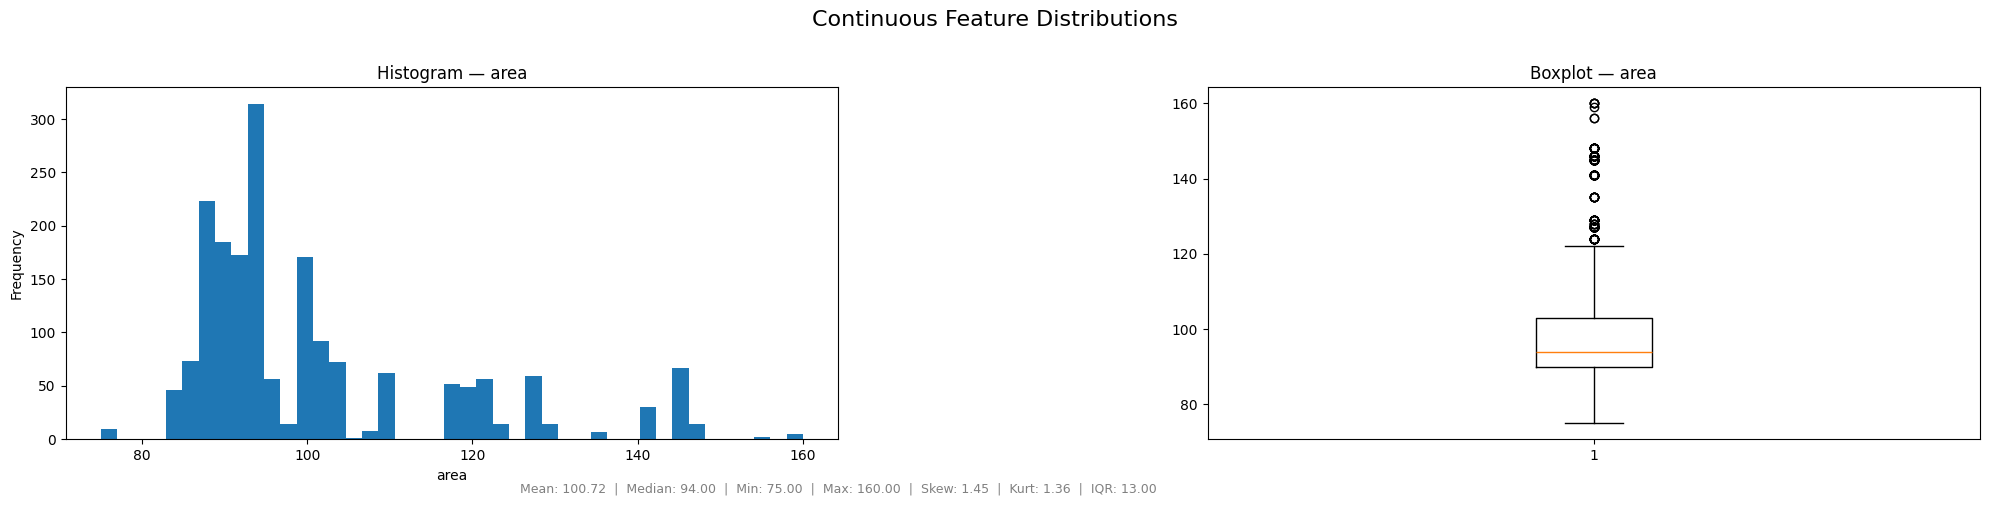

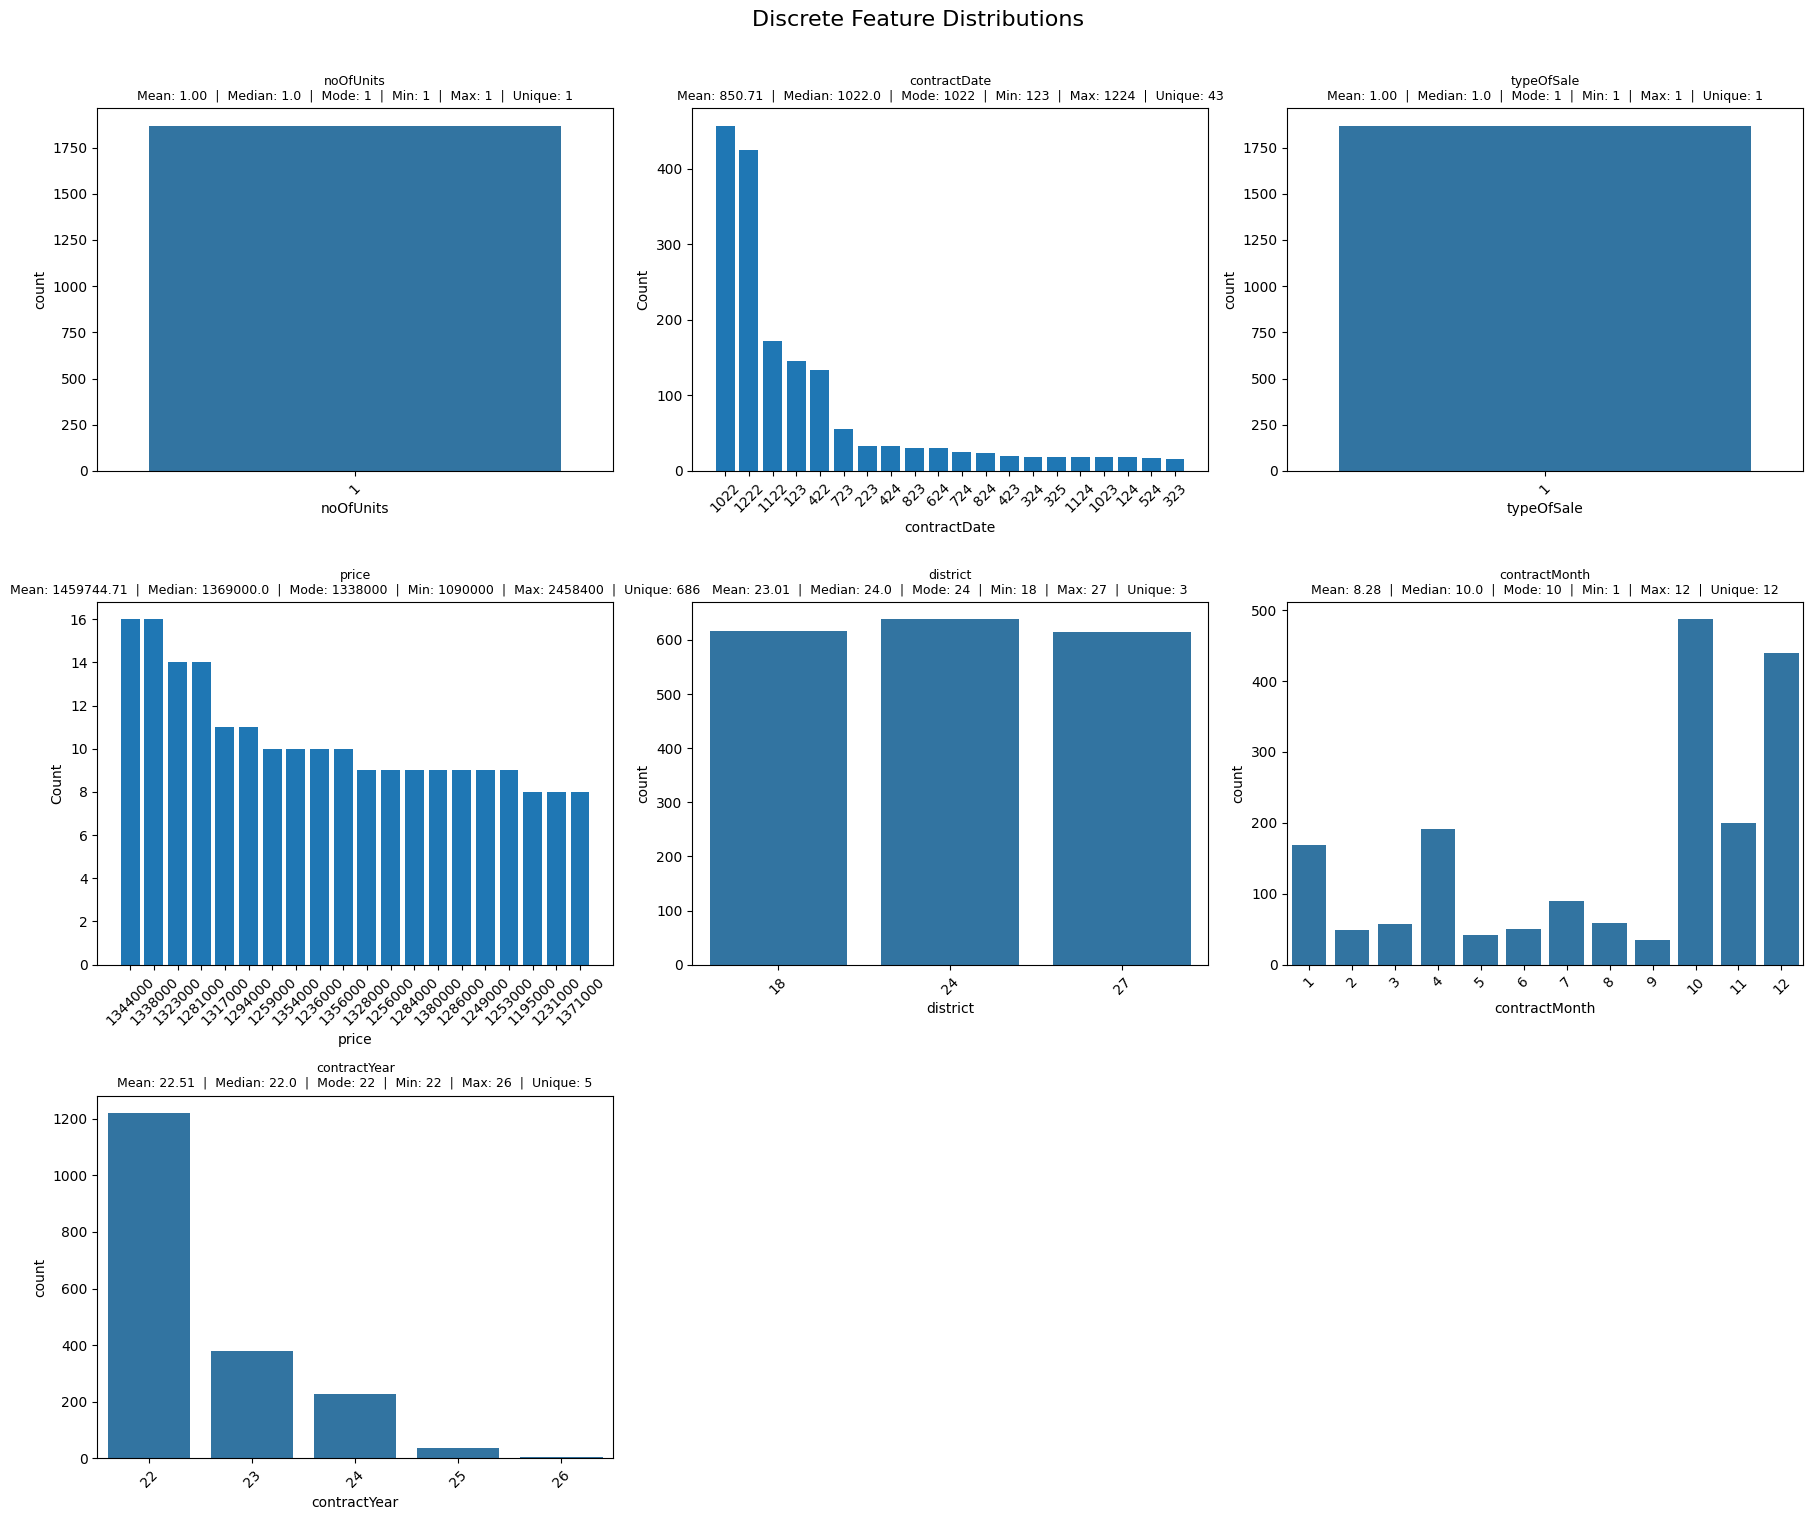

Value counts for noOfUnits:
noOfUnits
1    1869
Name: count, dtype: Int64
Total count: 1869


Value counts for contractDate:
contractDate
123     146
124      18
125       4
126       1
223      33
224      12
225       4
323      16
324      19
325      19
326       3
422     134
423      20
424      33
425       4
522       9
523      16
524      17
622       4
623      14
624      30
625       2
722       9
723      55
724      25
725       1
822       5
823      30
824      24
922       5
923      14
924      15
925       1
1022    457
1023     18
1024     12
1122    172
1123      9
1124     18
1125      1
1222    425
1223      9
1224      6
Name: count, dtype: Int64
Total count: 1869


Value counts for typeOfSale:
typeOfSale
1    1869
Name: count, dtype: Int64
Total count: 1869


Value counts for price:
price
1090000    1
1095000    1
1100000    1
1108000    1
1116000    1
          ..
2320000    1
2340000    1
2347000    1
2372000    1
2458400    1
Name: count, Length: 686, dtype

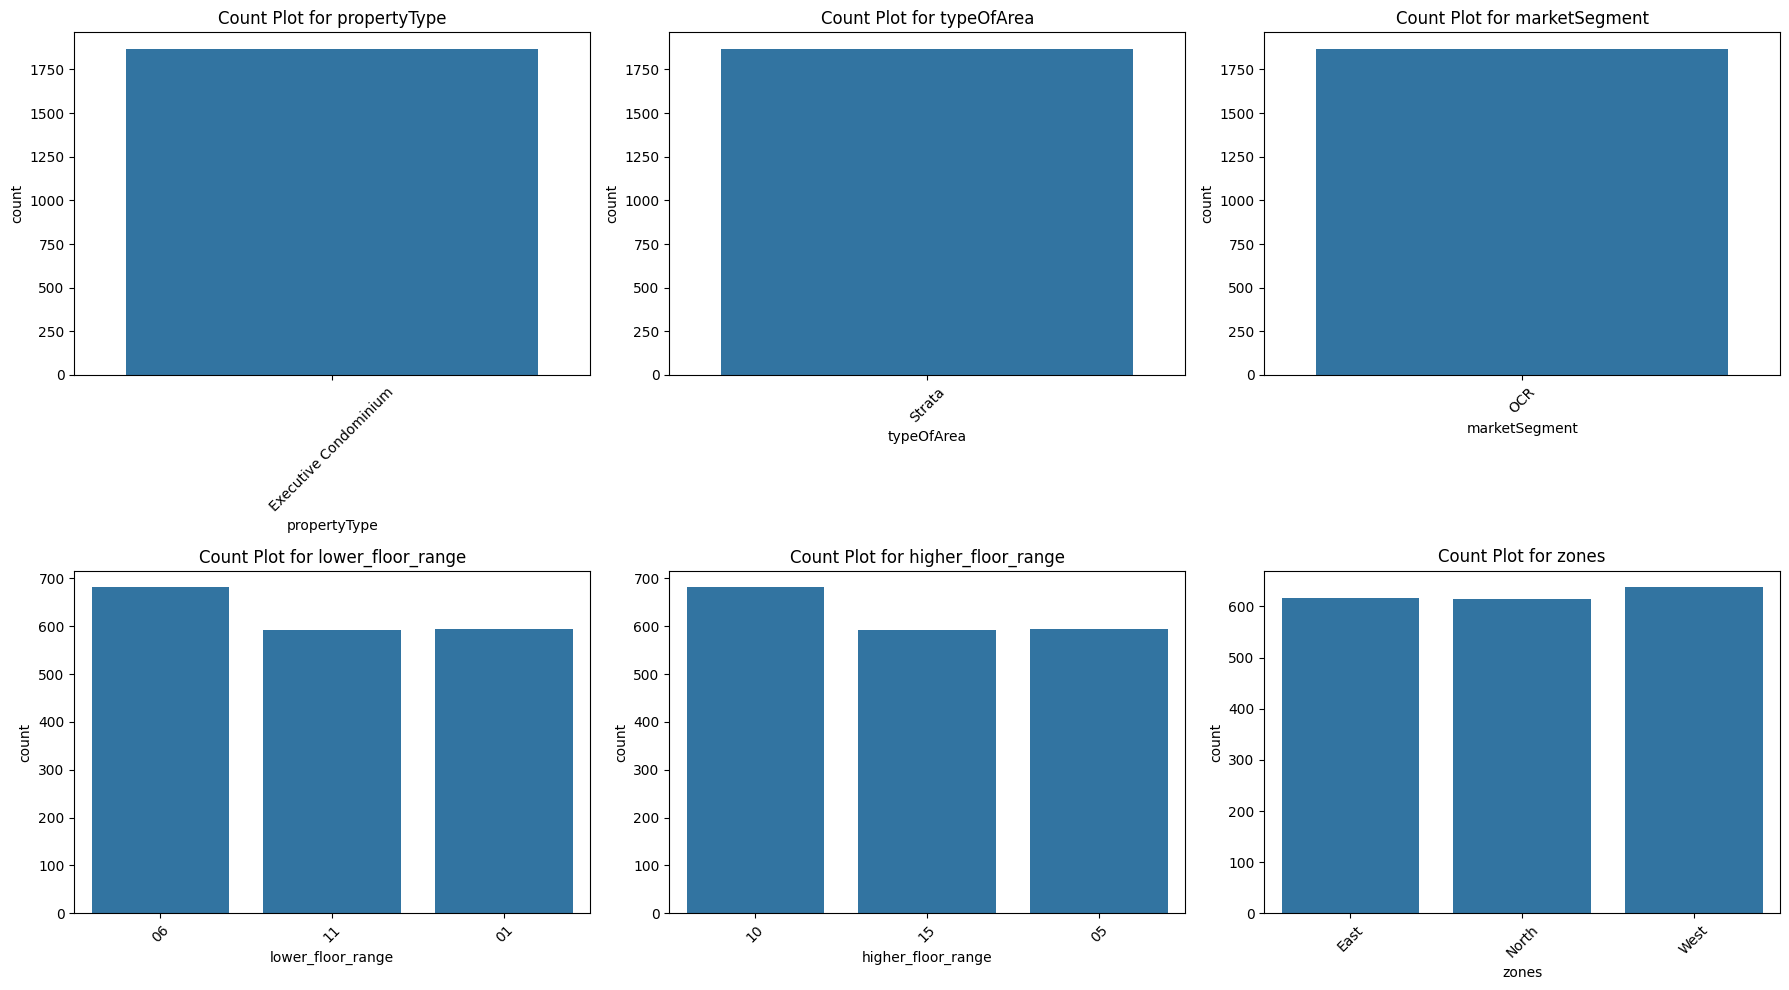

Value counts for propertyType:
propertyType
Executive Condominium    1869
Name: count, dtype: int64
Total count: 1869


Value counts for typeOfArea:
typeOfArea
Strata    1869
Name: count, dtype: int64
Total count: 1869


Value counts for marketSegment:
marketSegment
OCR    1869
Name: count, dtype: int64
Total count: 1869


Value counts for lower_floor_range:
lower_floor_range
06    682
01    595
11    592
Name: count, dtype: int64
Total count: 1869


Value counts for higher_floor_range:
higher_floor_range
10    682
05    595
15    592
Name: count, dtype: int64
Total count: 1869


Value counts for zones:
zones
West     638
East     616
North    615
Name: count, dtype: int64
Total count: 1869




In [74]:
plot_continuous_feature_distributions(df_lease_94, float_columns)
plot_discrete_feature_distributions(df_lease_94, int_columns)
plot_categorical_feature_countplots(df_lease_94, str_columns)

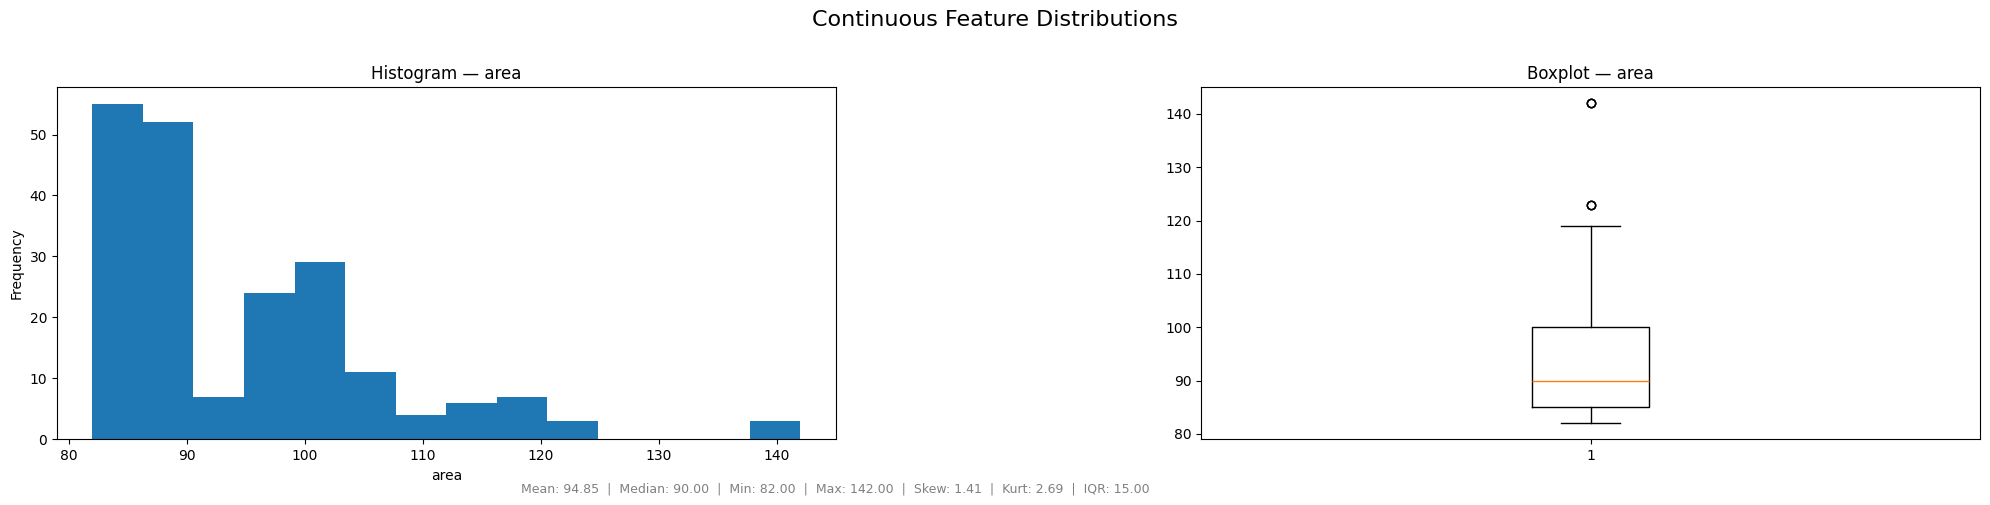

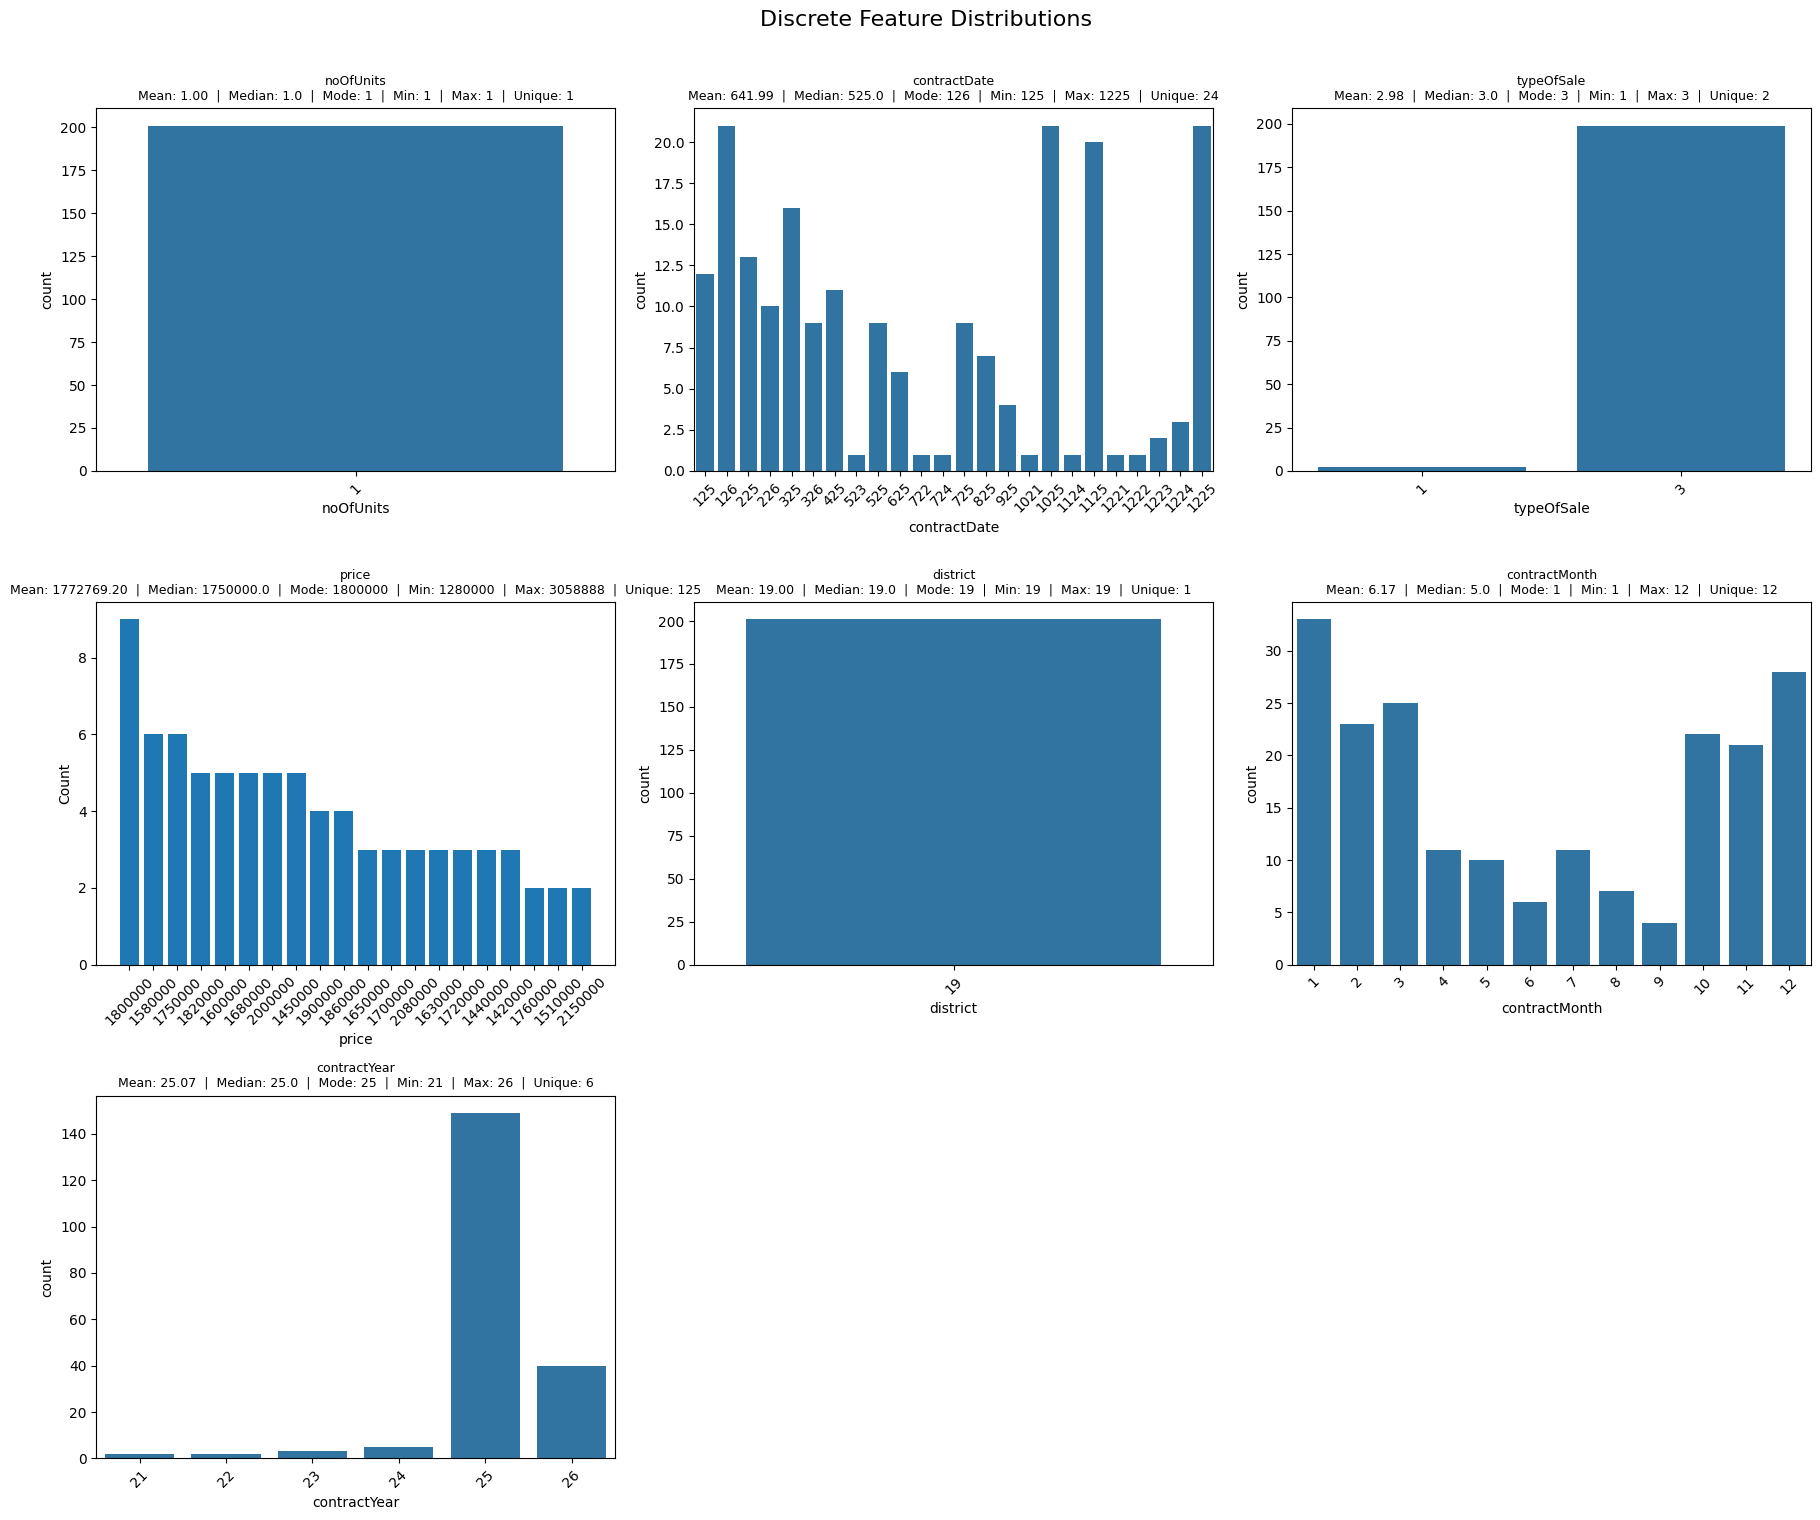

Value counts for noOfUnits:
noOfUnits
1    201
Name: count, dtype: Int64
Total count: 201


Value counts for contractDate:
contractDate
125     12
126     21
225     13
226     10
325     16
326      9
425     11
523      1
525      9
625      6
722      1
724      1
725      9
825      7
925      4
1021     1
1025    21
1124     1
1125    20
1221     1
1222     1
1223     2
1224     3
1225    21
Name: count, dtype: Int64
Total count: 201


Value counts for typeOfSale:
typeOfSale
1      2
3    199
Name: count, dtype: Int64
Total count: 201


Value counts for price:
price
1280000    2
1281000    1
1286000    1
1300000    1
1360000    1
          ..
2610000    1
2700000    1
2718000    1
2760000    1
3058888    1
Name: count, Length: 125, dtype: Int64
Total count: 201


Value counts for district:
district
19    201
Name: count, dtype: Int64
Total count: 201


Value counts for contractMonth:
contractMonth
1     33
2     23
3     25
4     11
5     10
6      6
7     11
8      7
9      4
10 

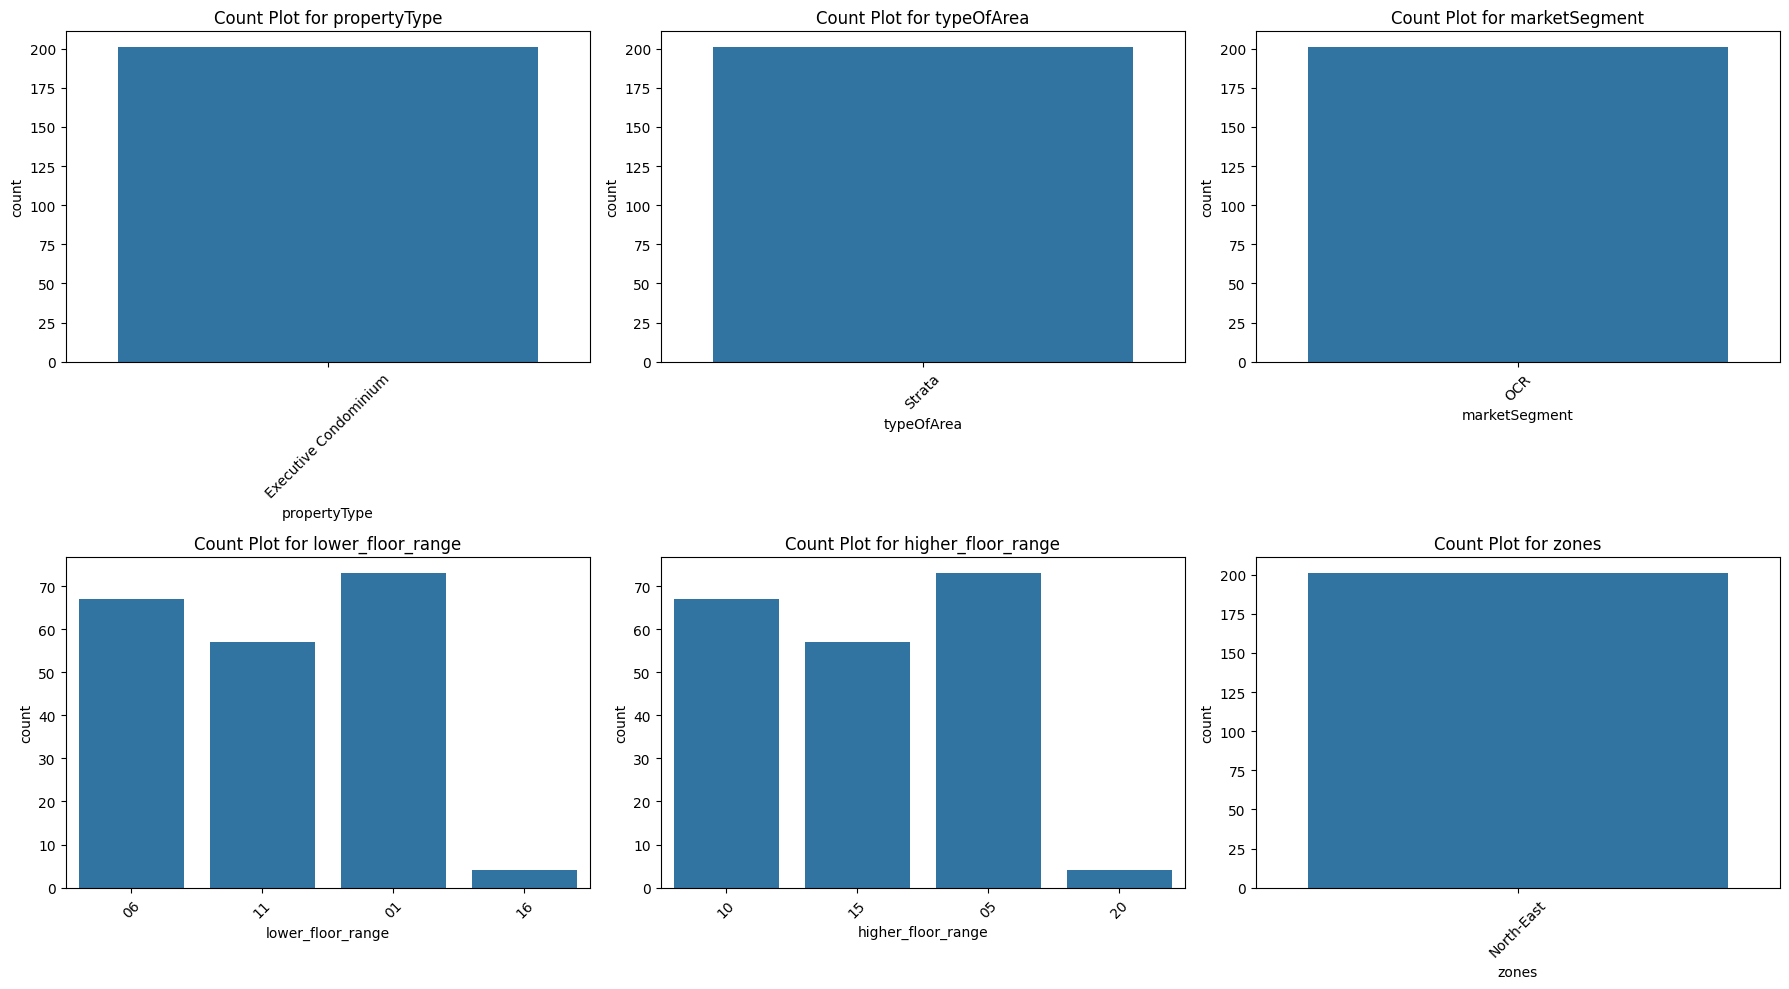

Value counts for propertyType:
propertyType
Executive Condominium    201
Name: count, dtype: int64
Total count: 201


Value counts for typeOfArea:
typeOfArea
Strata    201
Name: count, dtype: int64
Total count: 201


Value counts for marketSegment:
marketSegment
OCR    201
Name: count, dtype: int64
Total count: 201


Value counts for lower_floor_range:
lower_floor_range
01    73
06    67
11    57
16     4
Name: count, dtype: int64
Total count: 201


Value counts for higher_floor_range:
higher_floor_range
05    73
10    67
15    57
20     4
Name: count, dtype: int64
Total count: 201


Value counts for zones:
zones
North-East    201
Name: count, dtype: int64
Total count: 201




In [75]:
plot_continuous_feature_distributions(df_lease_89, float_columns)
plot_discrete_feature_distributions(df_lease_89, int_columns)
plot_categorical_feature_countplots(df_lease_89, str_columns)

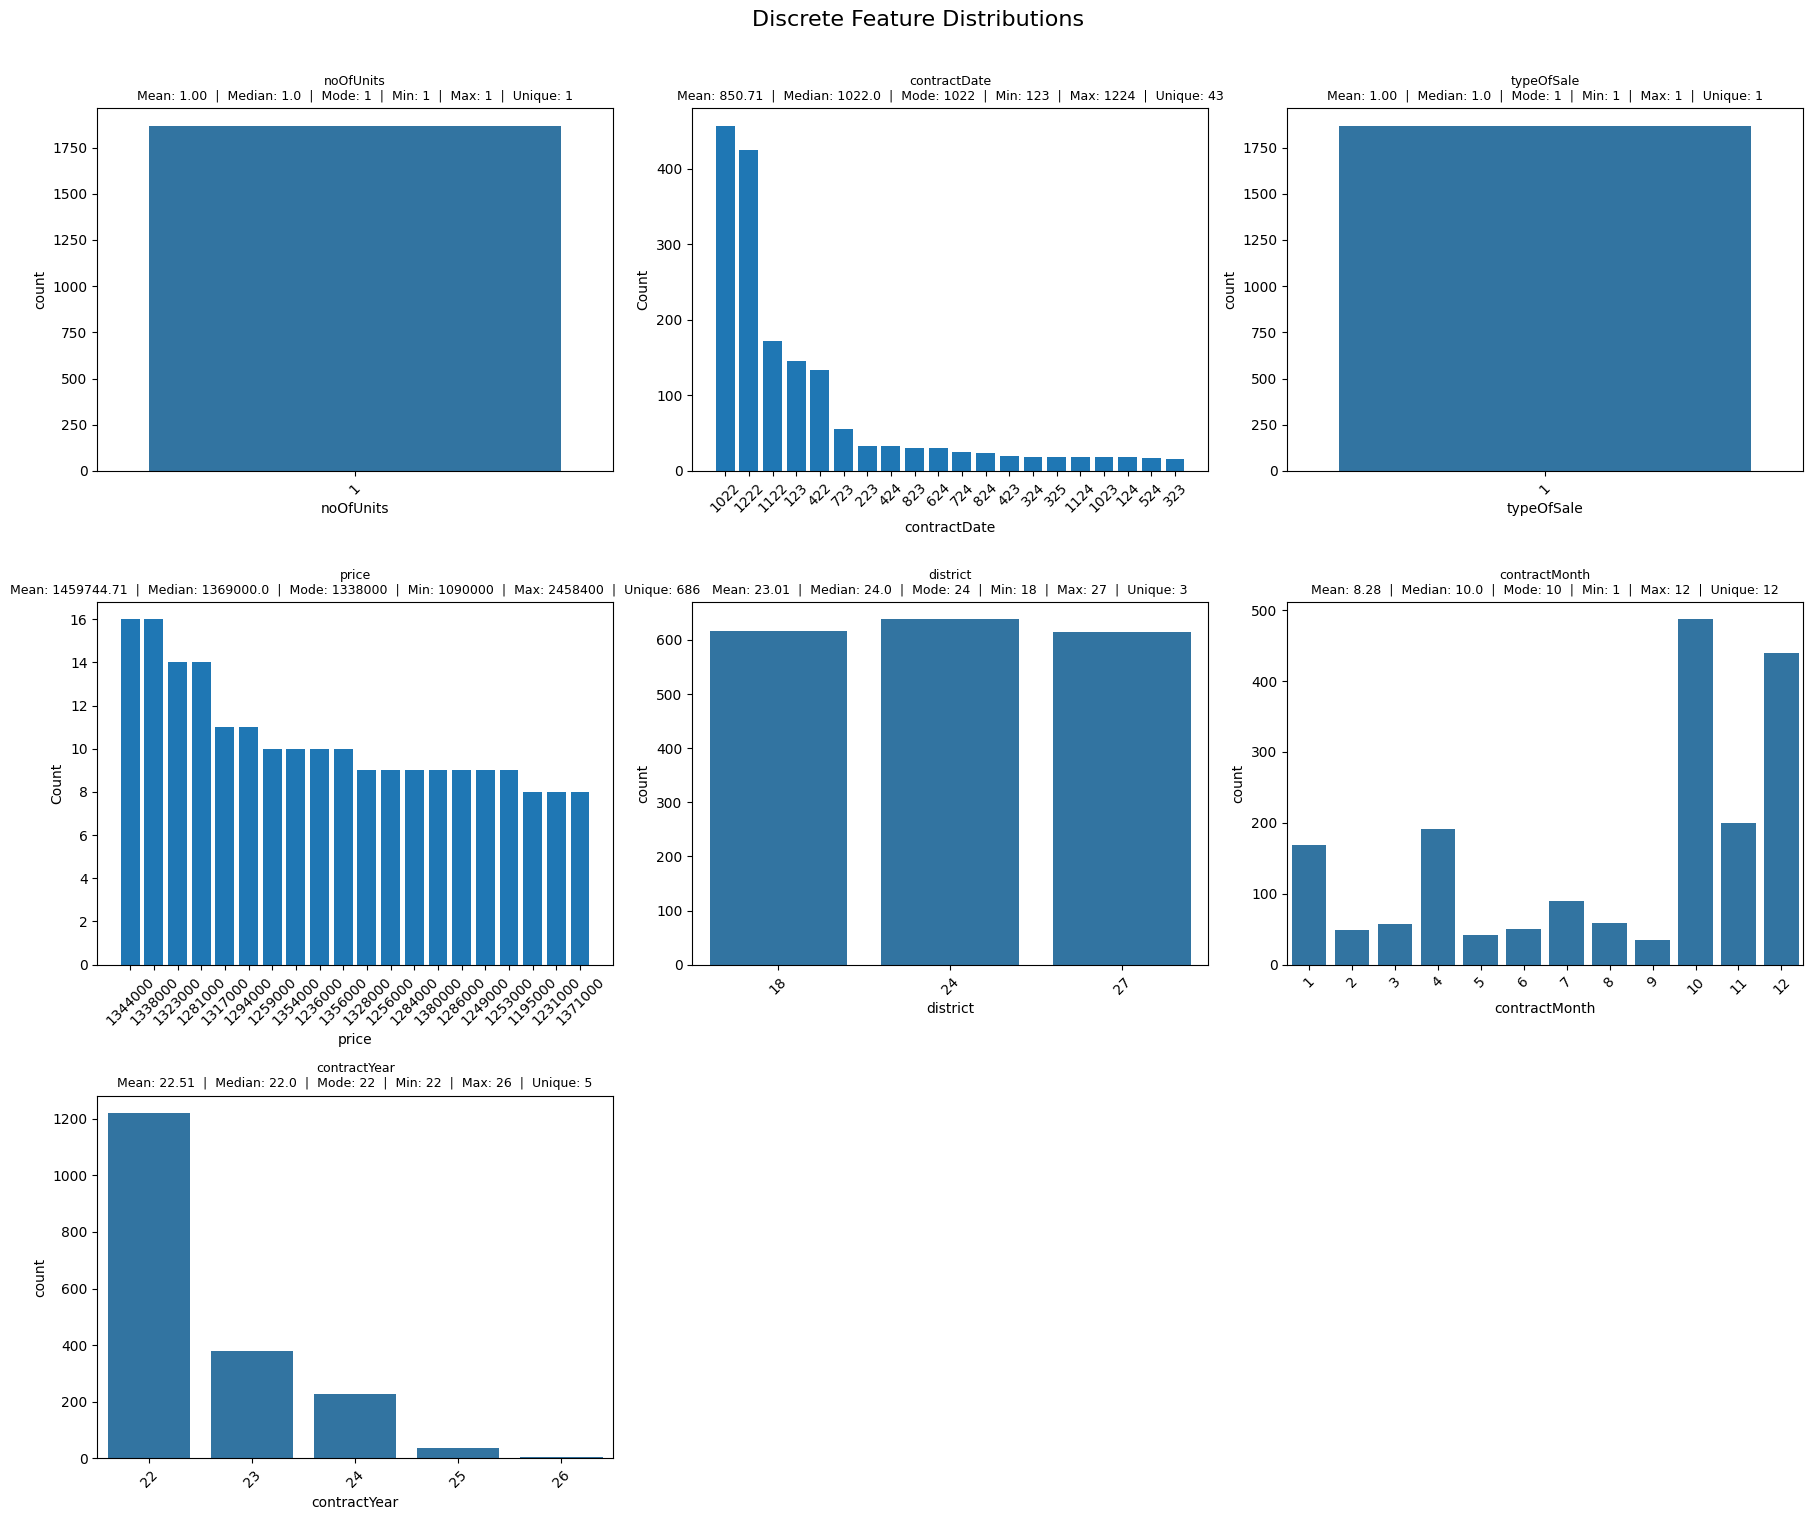

Value counts for noOfUnits:
noOfUnits
1    1869
Name: count, dtype: Int64
Total count: 1869


Value counts for contractDate:
contractDate
123     146
124      18
125       4
126       1
223      33
224      12
225       4
323      16
324      19
325      19
326       3
422     134
423      20
424      33
425       4
522       9
523      16
524      17
622       4
623      14
624      30
625       2
722       9
723      55
724      25
725       1
822       5
823      30
824      24
922       5
923      14
924      15
925       1
1022    457
1023     18
1024     12
1122    172
1123      9
1124     18
1125      1
1222    425
1223      9
1224      6
Name: count, dtype: Int64
Total count: 1869


Value counts for typeOfSale:
typeOfSale
1    1869
Name: count, dtype: Int64
Total count: 1869


Value counts for price:
price
1090000    1
1095000    1
1100000    1
1108000    1
1116000    1
          ..
2320000    1
2340000    1
2347000    1
2372000    1
2458400    1
Name: count, Length: 686, dtype

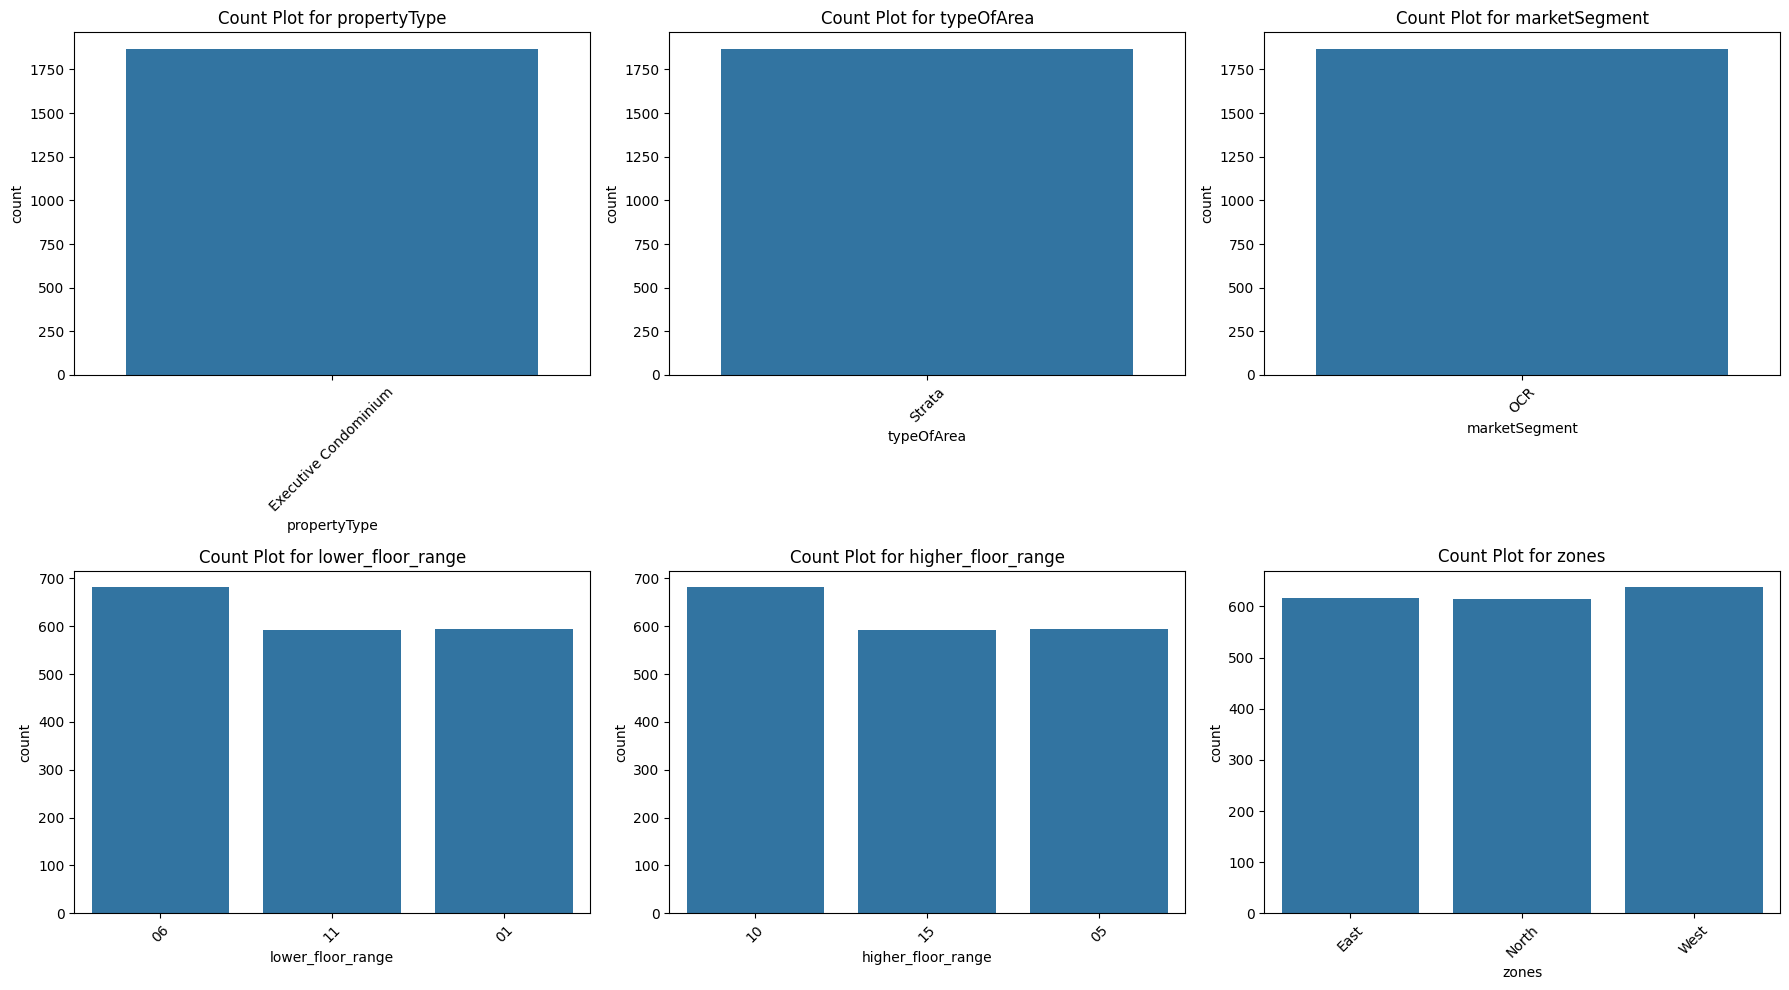

Value counts for propertyType:
propertyType
Executive Condominium    1869
Name: count, dtype: int64
Total count: 1869


Value counts for typeOfArea:
typeOfArea
Strata    1869
Name: count, dtype: int64
Total count: 1869


Value counts for marketSegment:
marketSegment
OCR    1869
Name: count, dtype: int64
Total count: 1869


Value counts for lower_floor_range:
lower_floor_range
06    682
01    595
11    592
Name: count, dtype: int64
Total count: 1869


Value counts for higher_floor_range:
higher_floor_range
10    682
05    595
15    592
Name: count, dtype: int64
Total count: 1869


Value counts for zones:
zones
West     638
East     616
North    615
Name: count, dtype: int64
Total count: 1869




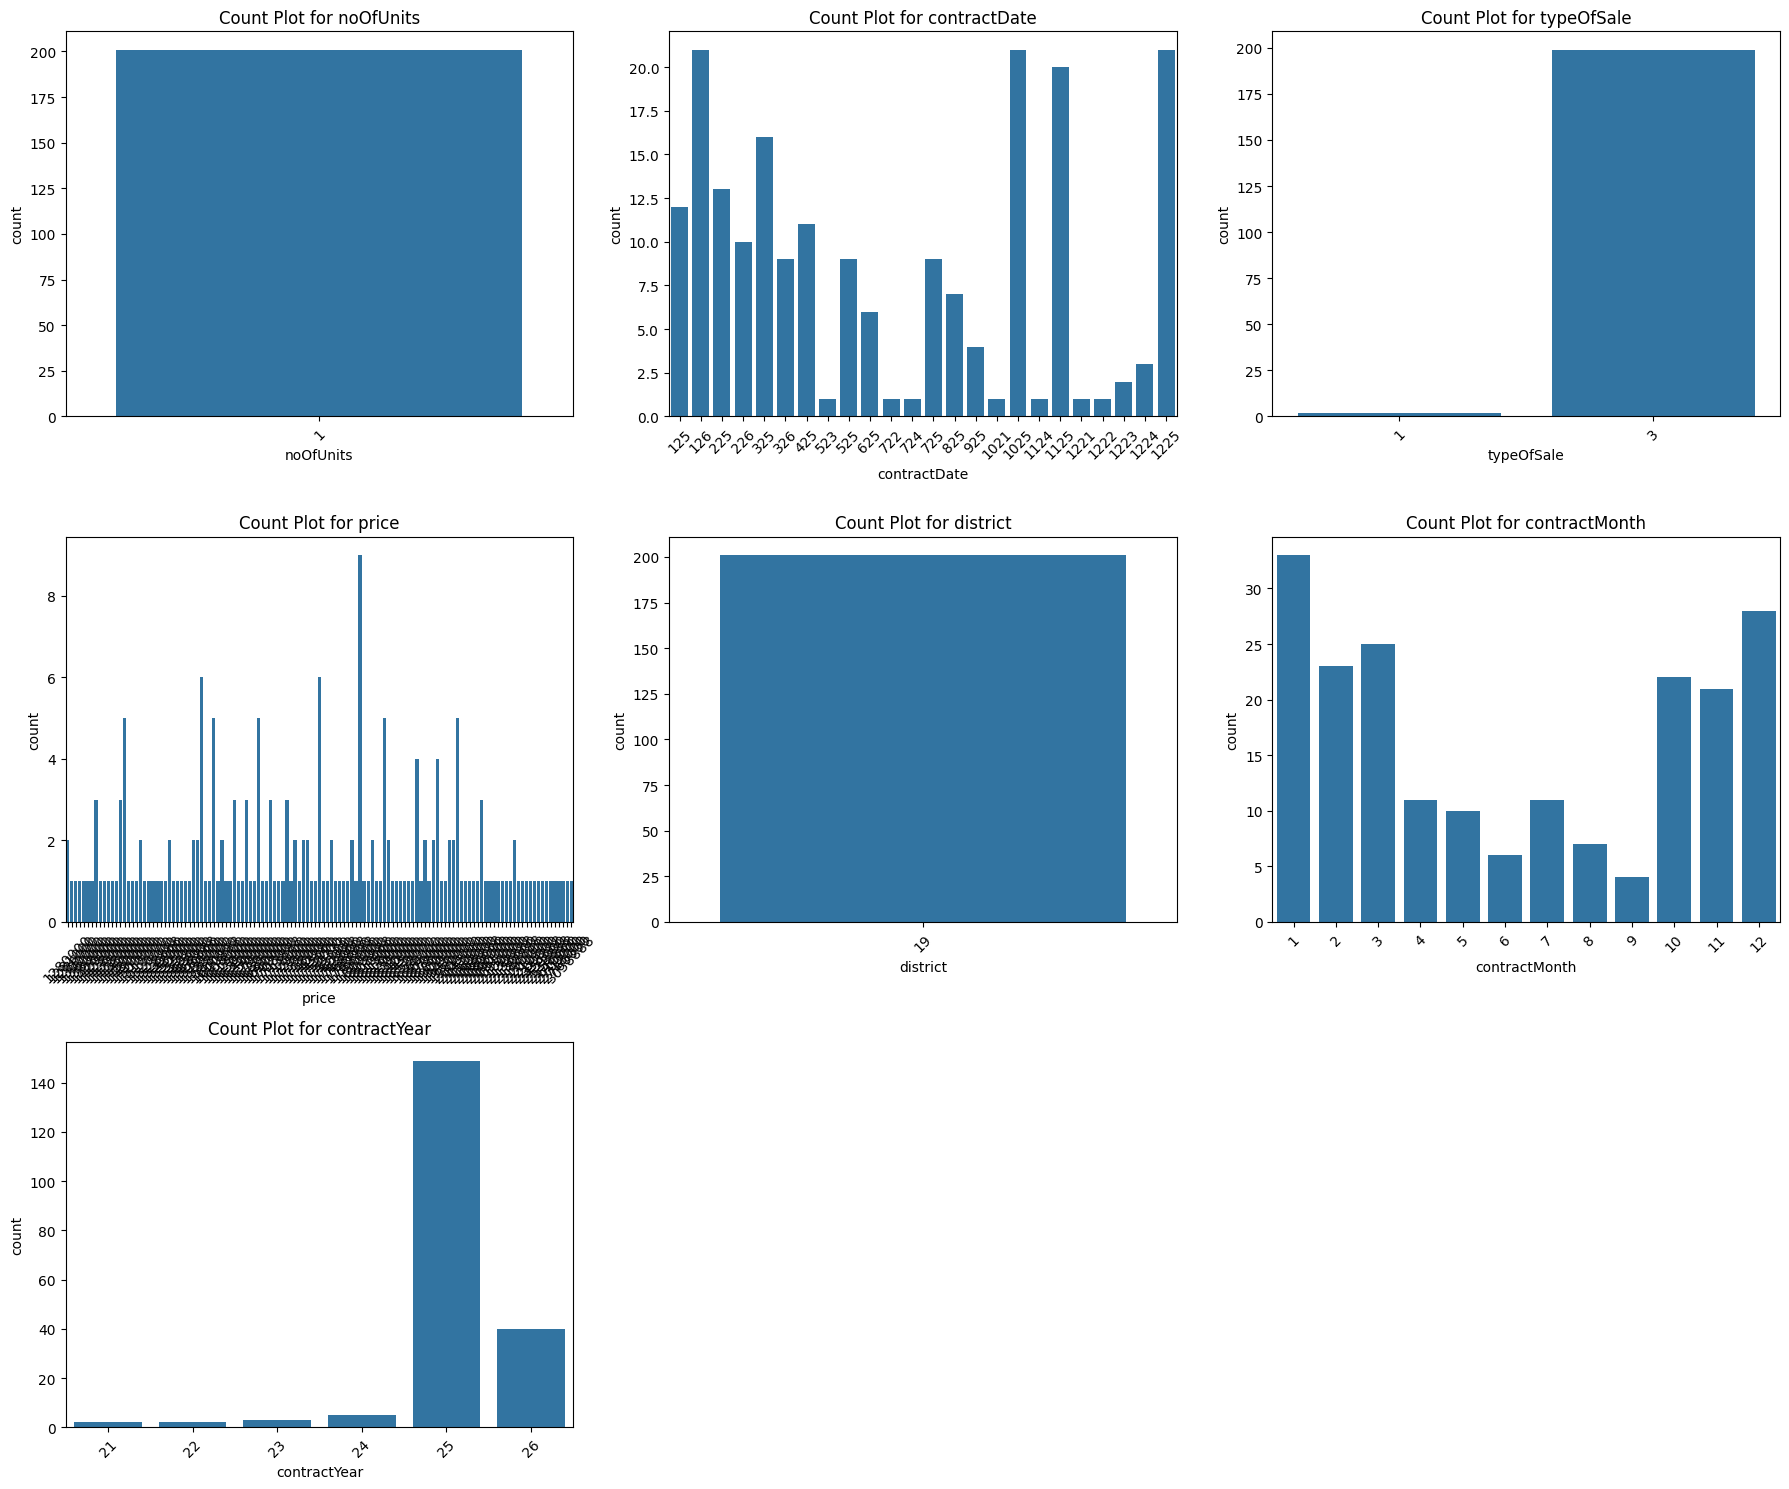

Value counts for noOfUnits:
noOfUnits
1    201
Name: count, dtype: Int64
Total count: 201


Value counts for contractDate:
contractDate
1225    21
1025    21
126     21
1125    20
325     16
225     13
125     12
425     11
226     10
525      9
725      9
326      9
825      7
625      6
925      4
1224     3
1223     2
1222     1
523      1
1221     1
1021     1
722      1
724      1
1124     1
Name: count, dtype: Int64
Total count: 201


Value counts for typeOfSale:
typeOfSale
3    199
1      2
Name: count, dtype: Int64
Total count: 201


Value counts for price:
price
1800000    9
1580000    6
1750000    6
1820000    5
1600000    5
          ..
1435000    1
1565000    1
1743880    1
1525000    1
1560800    1
Name: count, Length: 125, dtype: Int64
Total count: 201


Value counts for district:
district
19    201
Name: count, dtype: Int64
Total count: 201


Value counts for contractMonth:
contractMonth
1     33
12    28
3     25
2     23
10    22
11    21
4     11
7     11
5     10
8  

In [70]:
plot_categorical_feature_countplots(df_lease_89, int_columns)